# 09 — Haiku vs Gemma: Performance Comparison

Compare two LLMs on the **unconditioned** SciVer evaluation:

- **Haiku-4.5** — `data/processed/faithfulness_dataset.csv` (run 1, 5 trials/item).
- **Gemma-4-12B (QAT)** — `data/processed/faithfulness_dataset_2.csv` (5 trials/item).

Goals:
1. Check whether the two files are structurally comparable.
2. Pair them on the **same SciVer claims**.
3. Test whether the per-item accuracy difference is statistically significant, choosing the test by checking its assumptions.

**Headline result:** on the 279 shared val single-chart claims, Gemma (75.8%) significantly beats Haiku (67.0%) — Wilcoxon signed-rank p=1.6e-4, McNemar p=3.8e-3.

## 1. Setup and load both datasets

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")

cwd = Path.cwd().resolve()
REPO_ROOT = cwd if (cwd / "scripts").exists() else cwd.parent
PROC = REPO_ROOT / "data" / "processed"

haiku = pd.read_csv(PROC / "faithfulness_dataset.csv")
gemma = pd.read_csv(PROC / "faithfulness_dataset_2.csv")
print("Haiku:", haiku.shape, "| Gemma:", gemma.shape)

Haiku: (817, 29) | Gemma: (515, 9)


## 2. Are the two files structurally comparable?

They are **not** drop-in twins: different number of rows, different columns, different item populations. Gemma's file has no difficulty dimensions and is validation-only, and it includes multi-chart (`chart_chart`) items and extra claim types that Haiku's file does not.

In [2]:
print("columns only in Haiku:", sorted(set(haiku.columns) - set(gemma.columns)))
print("columns only in Gemma:", sorted(set(gemma.columns) - set(haiku.columns)))
print("shared columns:", sorted(set(haiku.columns) & set(gemma.columns)))

print("\nGemma split:", gemma["split"].unique().tolist())
print("Gemma evidence_kind:\n", gemma["evidence_kind"].value_counts().to_string())
print("\nGemma claim_type:\n", gemma["claim_type"].value_counts().to_string())
print("\nGemma accuracy_rate values:", sorted(gemma["accuracy_rate"].unique()),
      "-> 0.2 steps imply 5 trials/item")

columns only in Haiku: ['claim', 'dim_AS', 'dim_AT', 'dim_CL', 'dim_GS', 'dim_KNf', 'dim_MA', 'dim_MCr', 'dim_MCu', 'dim_QLl', 'dim_QLq', 'dim_SNs', 'dim_VL', 'dim_VO', 'image_path', 'item_id', 'label', 'paperid', 'pred_frac_correct', 'pred_frac_entailed', 'pred_majority_correct', 'pred_majority_label', 'pred_n_correct', 'pred_n_entailed', 'pred_n_trials', 'pred_unanimous', 'source', 'vtype']
columns only in Gemma: ['accuracy_rate', 'evidence_kind', 'gold_verdict', 'gold_yes_no', 'model_id', 'sample_id', 'source_index', 'split']
shared columns: ['claim_type']

Gemma split: ['val']
Gemma evidence_kind:
 evidence_kind
single_chart    279
chart_chart     236

Gemma claim_type:
 claim_type
direct        140
analytical    139
parallel      121
sequential    115

Gemma accuracy_rate values: [0.0, 0.2, 0.4, 0.6, 0.8, 1.0] -> 0.2 steps imply 5 trials/item


## 3. Pair the datasets on the same claims

Haiku item ids look like `sciver_val_<idx>` / `sciver_test_<idx>`; Gemma carries a `source_index` and a `sample_id` that embeds the paper id. We join Haiku's **val** items to Gemma on the index, then **verify** the pairing by confirming `paperid` and `claim_type` match on every joined row.

In [3]:
# Parse split + index out of the Haiku item_id.
ids = haiku["item_id"].str.extract(r"sciver_(?P<sp>val|test)_(?P<idx>\d+)")
haiku = haiku.assign(sp=ids["sp"], idx=ids["idx"].astype(int))

# Parse paperid out of the Gemma sample_id (val_<n>_<paperid>_<claim_type>_<k>).
gemma = gemma.assign(
    paperid=gemma["sample_id"].str.extract(
        r"^val_\d+_(.+?)_(?:direct|analytical|parallel|sequential)_\d+$"
    )[0]
)

haiku_val = haiku[haiku["sp"] == "val"]
paired = haiku_val.merge(gemma, left_on="idx", right_on="source_index", suffixes=("_h", "_g"))

print(f"Haiku val items: {len(haiku_val)} | Gemma items: {len(gemma)} | matched pairs: {len(paired)}")
print("paperid agreement   :", (paired["paperid_h"] == paired["paperid_g"]).mean())
print("claim_type agreement:", (paired["claim_type_h"] == paired["claim_type_g"]).mean())
print("\nGemma items with no Haiku counterpart:", len(gemma) - len(paired),
      "(all chart_chart / parallel+sequential)")
assert (paired["paperid_h"] == paired["paperid_g"]).all(), "pairing mismatch!"

Haiku val items: 279 | Gemma items: 515 | matched pairs: 279
paperid agreement   : 1.0
claim_type agreement: 1.0

Gemma items with no Haiku counterpart: 236 (all chart_chart / parallel+sequential)


## 4. Per-item accuracy on the shared claims

Both models were run **unconditioned with 5 trials per item**, so each item has a fraction-correct in {0, 0.2, ..., 1.0}. This paired design (same claims, two models) is what lets us use a paired test.

In [4]:
h = paired["pred_frac_correct"].to_numpy(float)  # Haiku
g = paired["accuracy_rate"].to_numpy(float)       # Gemma
n = len(paired)
diff = h - g

print(f"paired items                : {n}")
print(f"Haiku mean per-item accuracy : {h.mean():.4f}")
print(f"Gemma mean per-item accuracy : {g.mean():.4f}")
print(f"mean difference (Haiku-Gemma): {diff.mean():+.4f}")
print(f"items where they tie         : {int((diff == 0).sum())} / {n}")

paired items                : 279
Haiku mean per-item accuracy : 0.6703
Gemma mean per-item accuracy : 0.7584
mean difference (Haiku-Gemma): -0.0882
items where they tie         : 131 / 279


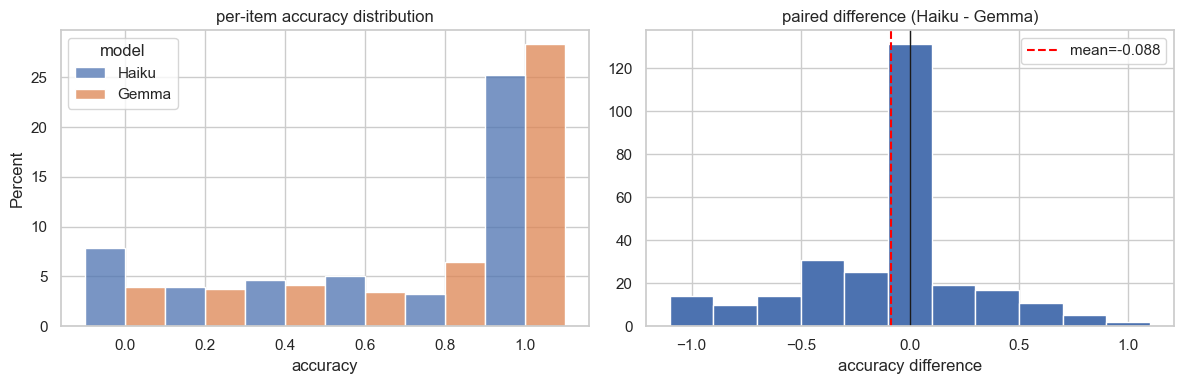

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Per-model distribution of per-item accuracy.
acc_long = pd.DataFrame({"Haiku": h, "Gemma": g}).melt(var_name="model", value_name="accuracy")
sns.histplot(data=acc_long, x="accuracy", hue="model", multiple="dodge",
             bins=[-0.1, 0.1, 0.3, 0.5, 0.7, 0.9, 1.1], stat="percent", ax=axes[0])
axes[0].set_title("per-item accuracy distribution")

# Distribution of paired differences (Haiku - Gemma).
axes[1].hist(diff, bins=np.arange(-1.1, 1.2, 0.2))
axes[1].axvline(0, color="k", lw=1)
axes[1].axvline(diff.mean(), color="red", ls="--", label=f"mean={diff.mean():.3f}")
axes[1].set_title("paired difference (Haiku - Gemma)")
axes[1].set_xlabel("accuracy difference")
axes[1].legend()
plt.tight_layout()
plt.show()

## 5. Choosing the test — check the assumptions

The data are **paired** (same claims), so we want a paired test. A paired *t*-test requires the per-item differences to be approximately **normal**. We check that with Shapiro-Wilk and the histogram above.

In [6]:
W, p_norm = stats.shapiro(diff)
print(f"Shapiro-Wilk on paired differences: W={W:.3f}, p={p_norm:.2e}")
print("normal?", "yes" if p_norm > 0.05 else "NO -> paired t-test assumption violated")
print(f"(differences are discrete and bounded, with {int((diff==0).sum())} exact ties at 0)")

Shapiro-Wilk on paired differences: W=0.908, p=4.58e-12
normal? NO -> paired t-test assumption violated
(differences are discrete and bounded, with 131 exact ties at 0)


Normality is clearly rejected (and the differences are discrete/bounded). So we **do not** rely on the paired *t*-test. Instead:

- **Primary — Wilcoxon signed-rank test:** the paired, non-parametric counterpart, appropriate for non-normal ordinal/bounded paired data. It tests whether the per-item accuracy differences are centered at zero.
- **Complementary — McNemar's test:** the standard test for comparing two classifiers on the *same* items. We binarize each item to "majority-correct" (≥3/5 trials) and test whether the discordant pairs are balanced.

The paired *t*-test is reported only for reference.

In [7]:
# Primary: Wilcoxon signed-rank (two-sided), plus a one-sided check on direction.
w_stat, p_w = stats.wilcoxon(h, g, zero_method="wilcox")
p_w_dir = stats.wilcoxon(h, g, zero_method="wilcox", alternative="less").pvalue  # Haiku < Gemma
print(f"Wilcoxon signed-rank: W={w_stat:.1f}, p={p_w:.3e}")
print(f"  one-sided (Haiku < Gemma): p={p_w_dir:.3e}")

# Reference only: paired t-test.
t_stat, p_t = stats.ttest_rel(h, g)
print(f"\n[reference] paired t-test: t={t_stat:.3f}, p={p_t:.3e}")

Wilcoxon signed-rank: W=3552.0, p=1.633e-04
  one-sided (Haiku < Gemma): p=8.163e-05

[reference] paired t-test: t=-3.795, p=1.813e-04


In [9]:
# Complementary: McNemar on binary majority-correct (>=3 of 5 trials).
hc = (h >= 0.5).astype(int)
gc = (g >= 0.5).astype(int)
both = int(((hc == 1) & (gc == 1)).sum())
haiku_only = int(((hc == 1) & (gc == 0)).sum())  # Haiku correct, Gemma wrong
gemma_only = int(((hc == 0) & (gc == 1)).sum())  # Gemma correct, Haiku wrong
neither = int(((hc == 0) & (gc == 0)).sum())

print("Contingency (majority-correct):")
print(pd.DataFrame(
    [[both, gemma_only], [haiku_only, neither]],
    index=["Gemma correct", "Gemma wrong"], columns=["Haiku correct", "Haiku wrong"],
))
print(f"\nHaiku majority-correct rate: {hc.mean():.3f} | Gemma: {gc.mean():.3f}")

# Exact McNemar = binomial test on the discordant pairs.
n_disc = haiku_only + gemma_only
p_mcnemar = stats.binomtest(haiku_only, n_disc, 0.5).pvalue
print(f"discordant pairs: Haiku-only={haiku_only}, Gemma-only={gemma_only}")
print(f"Exact McNemar (binomial on {n_disc} discordant pairs): p={p_mcnemar:.3e}")

Contingency (majority-correct):
               Haiku correct  Haiku wrong
Gemma correct            162           51
Gemma wrong               25           41

Haiku majority-correct rate: 0.670 | Gemma: 0.763
discordant pairs: Haiku-only=25, Gemma-only=51
Exact McNemar (binomial on 76 discordant pairs): p=3.836e-03


## 6. Summary

In [10]:
summary = pd.DataFrame([
    {"test": "Wilcoxon signed-rank (primary)", "statistic": round(w_stat, 1), "p_value": p_w,
     "significant_0.05": p_w < 0.05},
    {"test": "McNemar exact (binary)", "statistic": n_disc, "p_value": p_mcnemar,
     "significant_0.05": p_mcnemar < 0.05},
    {"test": "paired t-test (reference)", "statistic": round(t_stat, 3), "p_value": p_t,
     "significant_0.05": p_t < 0.05},
])
print(f"Paired items: {n}  |  Haiku {h.mean():.1%}  vs  Gemma {g.mean():.1%}\n")
print(summary.to_string(index=False))

Paired items: 279  |  Haiku 67.0%  vs  Gemma 75.8%

                          test  statistic  p_value  significant_0.05
Wilcoxon signed-rank (primary)   3552.000 0.000163              True
        McNemar exact (binary)     76.000 0.003836              True
     paired t-test (reference)     -3.795 0.000181              True


## Conclusion

On the **279 shared, unconditioned, val single-chart claims**, all three tests agree: **Gemma-4-12B (QAT) significantly outperforms Haiku-4.5** (75.8% vs 67.0% per-item accuracy; Wilcoxon p≈1.6e-4, McNemar p≈3.8e-3). The Wilcoxon signed-rank test is the appropriate primary test because the design is paired and the per-item accuracy differences are not normal (Shapiro p≈5e-12).

**Scope / caveats**
- Valid only on the 279 overlapping items (val, single-chart, direct/analytical). It does **not** cover Haiku's test split or Gemma's `chart_chart` / parallel+sequential items, which the other model never saw.
- `accuracy_rate` is assumed to be fraction-correct over 5 trials (the 0.2 granularity supports this) — worth confirming with whoever produced dataset 2.
- Gemma here is the quantized (`qat`) variant.